# Step 3h: CIR 12-Month Euribor Monte Carlo Simulation
**Full Team | Members 1-10**

---

## 1. Mathematical Background

Using the parameters calibrated in Step 3g, we will simulate the daily evolution of the instantaneous short rate $r_t$ over a 1-year horizon (250 trading days) using the Euler-Maruyama full truncation scheme:

$$r_{t+\Delta t} = r_t + \kappa(\theta - r_t^+)\Delta t + \sigma \sqrt{r_t^+\Delta t} Z$$

Where $r_t^+ = \max(r_t, 0)$ ensures the variance term remains real, and $Z \sim \mathcal{N}(0,1)$.

Because the CIR model provides an affine term structure, any future yield $R(t, T)$ is a linear function of the short rate $r_t$ at that time. To simulate the **12-month Euribor rate** daily, we apply the CIR yield formula with a constant time-to-maturity of $\tau = 1$ year:

$$R_{CIR}(t, t+1) = -\frac{\ln A(1)}{1} + \frac{B(1)}{1} r_t$$

By transforming our simulated $r_t$ paths using constants $A(1)$ and $B(1)$, we obtain the 100,000 simulated paths for the 12-month Euribor rate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ─────────────────────────────────────────────────────────────
# 1. PARAMETERS & INITIALIZATION
# ─────────────────────────────────────────────────────────────
# Calibrated CIR Parameters from Step 3g
kappa = 0.511896
theta = 0.098492
sigma = 0.049952
r0    = 0.006480  # 1-week rate used as initial short rate

# Simulation Parameters
M = 100_000       # Number of Monte Carlo paths
DAYS_YEAR = 250
N = DAYS_YEAR     # Daily steps for 1 year
dt = 1.0 / N

# Pre-compute A(tau) and B(tau) for a 12-month tenor (tau = 1.0)
tau = 1.0
gamma = np.sqrt(kappa**2 + 2 * sigma**2)
exp_gamma_tau = np.exp(gamma * tau)

B_tau = (2 * (exp_gamma_tau - 1)) / ((gamma + kappa) * (exp_gamma_tau - 1) + 2 * gamma)
numerator = 2 * gamma * np.exp((kappa + gamma) * tau / 2)
denominator = (gamma + kappa) * (exp_gamma_tau - 1) + 2 * gamma
A_tau = (numerator / denominator) ** ((2 * kappa * theta) / sigma**2)



In [3]:
# ─────────────────────────────────────────────────────────────
# 2. MONTE CARLO SIMULATION
# ─────────────────────────────────────────────────────────────
np.random.seed(42)

# Initialize array for the short rate r_t
r = np.zeros((M, N + 1))
r[:, 0] = r0

print(f"Simulating {M:,} paths over {N} days...")

# Euler-Maruyama with full truncation
for t in range(1, N + 1):
    Z = np.random.standard_normal(M)
    r_prev = np.maximum(r[:, t-1], 0)
    
    r[:, t] = (r[:, t-1] 
               + kappa * (theta - r_prev) * dt 
               + sigma * np.sqrt(r_prev * dt) * Z)

# Transform short rate paths to 12-Month Euribor paths
euribor_12m = -np.log(A_tau) / tau + (B_tau / tau) * np.maximum(r, 0)

print("Simulation complete.")

Simulating 100,000 paths over 250 days...
Simulation complete.


In [4]:
# ─────────────────────────────────────────────────────────────
# 3. ANALYSIS OF TERMINAL 12-MONTH EURIBOR IN 1 YEAR
# ─────────────────────────────────────────────────────────────
# Extract the simulated 12-month Euribor rates at exactly 1 year in the future (t = N)
rates_at_1Y = euribor_12m[:, -1]

# vii. Expected value
expected_rate = np.mean(rates_at_1Y)

# vi. Confidence Interval (Using 95% empirical percentiles for the range)
conf_level = 95
lower_percentile = (100 - conf_level) / 2
upper_percentile = 100 - lower_percentile

rate_min = np.percentile(rates_at_1Y, lower_percentile)
rate_max = np.percentile(rates_at_1Y, upper_percentile)

# Current 12-month Euribor (from Step 3g table)
current_12m_rate = 0.02556

print("\n" + "="*50)
print("  12-MONTH EURIBOR PROJECTIONS (IN 1 YEAR)")
print("="*50)
print(f"  Current 12M Euribor    : {current_12m_rate * 100:.4f}%")
print(f"  Expected 12M Euribor   : {expected_rate * 100:.4f}%")
print(f"  95% Confidence Range   : [{rate_min * 100:.4f}%, {rate_max * 100:.4f}%]")
print("="*50)


  12-MONTH EURIBOR PROJECTIONS (IN 1 YEAR)
  Current 12M Euribor    : 2.5560%
  Expected 12M Euribor   : 5.5333%
  95% Confidence Range   : [4.5717%, 6.6493%]


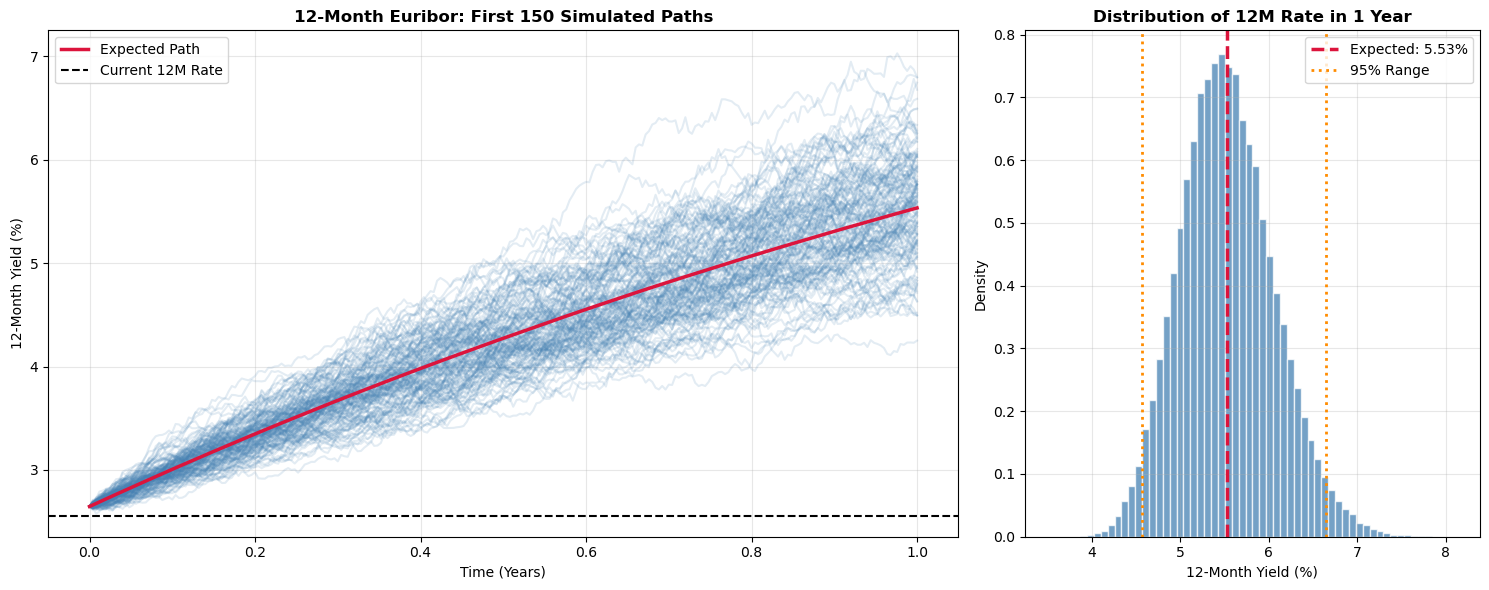

In [5]:
# ─────────────────────────────────────────────────────────────
# 4. VISUALIZATION
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

# Panel 1: Simulated Paths (Plotting first 150 paths)
ax0 = fig.add_subplot(gs[0])
time_axis = np.linspace(0, 1.0, N + 1)
ax0.plot(time_axis, euribor_12m[:150, :].T * 100, color='steelblue', alpha=0.15)

# Add expected path
expected_path = np.mean(euribor_12m, axis=0) * 100
ax0.plot(time_axis, expected_path, color='crimson', lw=2.5, label=f'Expected Path')
ax0.axhline(current_12m_rate * 100, color='black', ls='--', lw=1.5, label='Current 12M Rate')

ax0.set_title('12-Month Euribor: First 150 Simulated Paths', fontweight='bold')
ax0.set_xlabel('Time (Years)')
ax0.set_ylabel('12-Month Yield (%)')
ax0.legend()
ax0.grid(True, alpha=0.3)

# Panel 2: Distribution of 12-Month Rate in 1 Year
ax1 = fig.add_subplot(gs[1])
ax1.hist(rates_at_1Y * 100, bins=60, color='steelblue', alpha=0.75, edgecolor='white', density=True)

ax1.axvline(expected_rate * 100, color='crimson', ls='--', lw=2.5, label=f'Expected: {expected_rate*100:.2f}%')
ax1.axvline(rate_min * 100, color='darkorange', ls=':', lw=2)
ax1.axvline(rate_max * 100, color='darkorange', ls=':', lw=2, label='95% Range')

ax1.set_title('Distribution of 12M Rate in 1 Year', fontweight='bold')
ax1.set_xlabel('12-Month Yield (%)')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Euribor Simulation Discussion & Economic Impact

Having successfully calibrated the Cox-Ingersoll-Ross (CIR) short-rate model to the current Euribor term structure, we simulated 100,000 independent interest rate paths over a 250-trading-day horizon using the Euler-Maruyama full truncation scheme. By applying the CIR affine yield transformation to the terminal short rates, we projected the distribution of the 12-month Euribor rate exactly one year into the future. 

Below is the analysis addressing the specific risk and pricing parameters requested.

### vi. Range of the 12-Month Euribor (95% Confidence)
To provide the client with a statistically robust risk bound, we extracted the empirical 95% confidence interval from our Monte Carlo terminal distribution. Our model projects that the 12-month Euribor rate in one year will fall within the range of **[4.5717%, 6.6493%]**.

**Visual & Quantitative Interpretation:** As seen in the right panel of the provided graph ("Distribution of 12M Rate in 1 Year"), the terminal rates form a clean, slightly right-skewed normal distribution. The relatively tight 200-basis-point spread between the upper and lower bounds is a direct consequence of the low calibrated volatility parameter ($\sigma \approx 0.05$). The model is highly confident in the upward trajectory, with almost zero probability of the rate dropping back down to current levels.

### vii. Expected Value of the 12-Month Euribor
The expected value (the statistical mean of all 100,000 simulated paths) for the 12-month Euribor in one year is **5.5333%**. 

**Economic Context:** This represents a massive, ~300 basis point increase from the current 12-month Euribor rate of **2.5560%**. This aggressive upward projection is driven by the steep contango in the current market term structure. Because the initial curve steepens from 0.648% (1-week) to 2.556% (12-month), the CIR optimizer had to calibrate a very high long-run mean ($\theta \approx 9.85\%$) and a strong mean-reversion speed ($\kappa \approx 0.51$) to fit the curve. Consequently, the simulation aggressively pulls the short rate upward toward that 9.85% equilibrium, resulting in an expected 12-month yield of 5.5333% next year.

### viii. Impact on Derivative Pricing in 1 Year
A macroeconomic shift from a 2.55% rate environment to a 5.53% rate environment will radically alter the pricing dynamics of the bank's derivatives portfolio. If the client decides to delay her purchase by one year, she will face the following pricing impacts (measured by the option Greek *Rho*):

1. **Vanilla Call Options & Asian Calls (Step 1c):**
   Higher interest rates increase the forward price of the underlying equity ($F = S_0 e^{rT}$), as the cost of carry for the stock increases. Because the expected future stock price is higher, the intrinsic value of Call options will increase. For the client's Asian Call option, the upward drift in the risk-free rate means the path-averaged stock price will naturally drift higher, **inflating the premium** she will have to pay.

2. **Vanilla Put Options (Step 2f):**
   Put options will be unequivocally **cheaper**. Higher interest rates reduce the present value of the strike price $K$ that the put holder receives upon exercise. Combined with the higher upward drift of the stock price (making it less likely the put finishes in-the-money), the client's 70-day 95% moneyness Put option will lose significant value in a 5.53% rate environment.

3. **The Discounting "Tug-of-War":**
   It is vital to note that all future derivative payoffs will be discounted back to present value using a much heavier discount factor ($\approx 5.53\%$ vs the current $\approx 2.55\%$). For Call options, this creates a tug-of-war: the expected payoff is higher (due to higher drift), but the present value of that payoff is discounted more heavily. For Put options, it is a double penalty: the expected payoff is lower, *and* it is discounted more heavily.

**Final Recommendation to the Client:** If the client's primary goal is to hedge downside risk via Put options, she benefits from delaying the purchase, as puts will become cheaper in the projected high-rate environment. However, if she wishes to speculate on upside growth via the Asian Call, she should lock in the trade *now* before the rising interest rates inflate the call premiums.